# TIỀN XỬ LÝ DỮ LIỆU (DATA PREPROCESSING)
**Nhiệm vụ của phần này:**
1. **Kiểm tra dataset:** Đếm xem số lượng ảnh các loại quần áo có đều nhau không.
2. **Chia tập Train và Test:** Chia dữ liệu theo tỷ lệ chuẩn 60/20/20 và giữ đều tỉ lệ các lớp (Stratified Sampling).
3. **Data Augmentation:** Xoay/lật ảnh ngẫu nhiên (Data Augmentation) để AI học được nhiều góc độ thực tế.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms

# Khởi tạo danh sách tên các nhãn để trực quan hóa
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Bước 1: Tải dữ liệu & Kiểm tra xem có bị "học lệch" không (Data Analysis)

* **Ý nghĩa:** Tải bộ ảnh quần áo `FashionMNIST` dùng PyTorch về và vẽ biểu đồ đếm xem mỗi loại (áo, quần, váy, giày...) có bao nhiêu ảnh.
* **Mục tiêu:** Đảm bảo dữ liệu cân bằng. Nếu một loại có quá nhiều ảnh (ví dụ 10,000 ảnh áo) mà loại khác quá ít (chỉ 100 ảnh váy), AI học xong sẽ bị "thiên vị" và luôn đoán bừa là áo.

Tổng số mẫu tập Train gốc: 60000 mẫu
Kích thước mỗi ảnh: torch.Size([1, 28, 28])


C:\Users\Admin\AppData\Local\Temp\ipykernel_26556\1820601864.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_labels, palette="viridis")


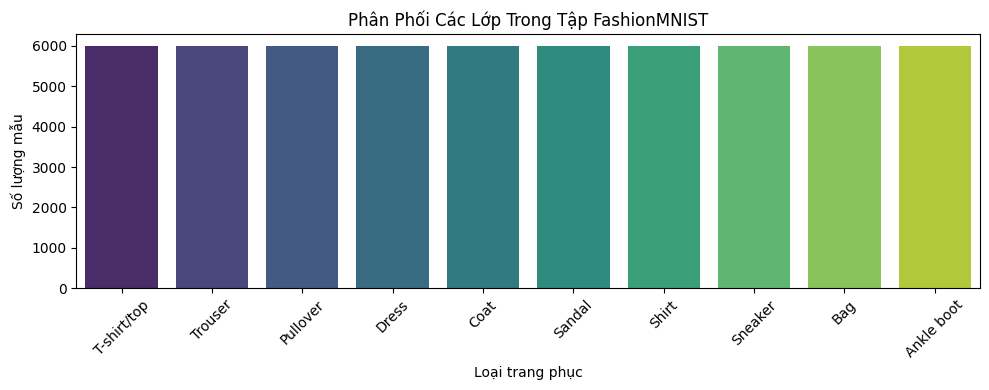

In [2]:
# Tải dữ liệu thô (chỉ chuyển thành Tensor để phân tích)
raw_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
raw_test = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

# Gộp nhãn để kiểm tra phân phối tổng thể
train_labels = raw_train.targets.numpy()
print(f"Tổng số mẫu tập Train gốc: {len(train_labels)} mẫu")
print(f"Kích thước mỗi ảnh: {raw_train[0][0].shape}")

# Vẽ biểu đồ phân phối tần suất các lớp
plt.figure(figsize=(10, 4))
sns.countplot(x=train_labels, palette="viridis")
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title("Phân Phối Các Lớp Trong Tập FashionMNIST")
plt.xlabel("Loại trang phục")
plt.ylabel("Số lượng mẫu")
plt.tight_layout()
plt.show()

## Bước 2: Chia tập dữ liệu 60/20/20 (Stratified Sampling)

* **Vấn đề:** Bộ dữ liệu mặc định chỉ chia sẵn thành 2 tập (Train 60k và Test 10k). Chúng ta bị thiếu tập **Validation** (tập dùng để "nếm thử" xem AI học có bị học vẹt - Overfitting hay không).
* **Giải pháp:** 
 1. Gộp toàn bộ dữ liệu lại thành 70,000 ảnh để xáo trộn ngẫu nhiên.
  2. Cắt lần 1: Trích ra 20% làm tập **Test** .
  3. Cắt lần 2: Lấy phần còn lại chia thành tập **Train** (60%) và **Validation** (20%).
* **Từ khóa "Stratified":** Đảm bảo dù có chia nhỏ ra thì tỉ lệ các loại quần áo trong mỗi tập con vẫn bằng chằn chặn nhau, không bị lệch pha.

In [3]:
# Gộp toàn bộ dữ liệu 70,000 mẫu
full_dataset = ConcatDataset([raw_train, raw_test])
all_labels = np.concatenate([raw_train.targets.numpy(), raw_test.targets.numpy()])
all_indices = np.arange(len(full_dataset))

# Lần cắt 1: Trích ra đúng 20% làm tập Test (14,000 mẫu)
temp_indices, test_indices, y_temp, y_test = train_test_split(
    all_indices, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

# Lần cắt 2: Cắt tập Temp thành Train (60% ~ 42,000 mẫu) và Validation (20% ~ 14,000 mẫu)
train_indices, val_indices, _, _ = train_test_split(
    temp_indices, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("--- Kết quả phân chia dữ liệu ---")
print(f"Số lượng mẫu tập Train (60%):      {len(train_indices)} mẫu")
print(f"Số lượng mẫu tập Validation (20%): {len(val_indices)} mẫu")
print(f"Số lượng mẫu tập Test (20%):       {len(test_indices)} mẫu")

--- Kết quả phân chia dữ liệu ---
Số lượng mẫu tập Train (60%):      42000 mẫu
Số lượng mẫu tập Validation (20%): 14000 mẫu
Số lượng mẫu tập Test (20%):       14000 mẫu


## Bước 3: Tăng cường hình ảnh (Data Augmentation) & Đóng gói dữ liệu (DataLoader)

* **Tăng cường dữ liệu (Data Augmentation):** Làm phong phú tập **Train** bằng cách xoay nhẹ ảnh hoặc lật ngang ngẫu nhiên. Giúp AI làm quen với nhiều góc chụp. *Lưu ý tinh tế:* Tuyệt đối không lật dọc ảnh quần áo vì thực tế không ai mặc đồ lộn ngược đầu xuống đất.
* **Tập Validation & Test:** Giữ nguyên ảnh gốc (chỉ thu nhỏ pixel về khoảng `[-1, 1]`) để chấm điểm AI khách quan.
* **DataLoader:** Đóng gói ảnh thành từng nhóm nhỏ (Batch size = 64) để nạp dần vào mạng CNN, giúp máy tính không bị "sập" do quá tải bộ nhớ.

In [ ]:
# Định nghĩa các bộ lọc biến đổi dữ liệu
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

raw_train_aug = datasets.FashionMNIST(root="./data", train=True, download=True, transform=train_transform)
raw_test_aug = datasets.FashionMNIST(root="./data", train=False, download=True, transform=train_transform)
full_train_dataset = ConcatDataset([raw_train_aug, raw_test_aug])

raw_train_eval = datasets.FashionMNIST(root="./data", train=True, download=True, transform=eval_transform)
raw_test_eval = datasets.FashionMNIST(root="./data", train=False, download=True, transform=eval_transform)
full_eval_dataset = ConcatDataset([raw_train_eval, raw_test_eval])

# Bọc các tập dữ liệu đã chia bằng các phép biến đổi tương ứng
# Dùng các index (0-69999) để trích xuất từ tập full (70k ảnh)
train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_eval_dataset, val_indices)
test_dataset = Subset(full_eval_dataset, test_indices)

# Khởi tạo DataLoader sẵn sàng nạp vào mạng CNN để huấn luyện
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("--- HOÀN TẤT TIỀN XỬ LÝ DỮ LIỆU SẴN SÀNG CHO VÒNG LẶP HUẤN LUYỆN ---")

--- HOÀN TẤT TIỀN XỬ LÝ DỮ LIỆU SẴN SÀNG CHO VÒNG LẶP HUẤN LUYỆN ---
